## Clusterization

task.py의 Task.representative_features를 확인해 보면 features들 중 무엇을 clusterization할 때 쓸 representative으로 내세울 것인지 정핧 수 있습니다. (주석으로)
Heuristic한 방법으로, 겹치지 않고 충분히 효과적인 clustering이 가능해 보이는 feature들을 추렸고 이 중에서 몇 개를 선택해야 합니다.
현재 생각중인 후보는

(1) [area_ratio, input_color_count, changed_ratio]

(2) [input_color_count, changed_ratio, removed_color_ratio]

(3) [area_ratio, input_color_count, changed_ratio, removed_color_ratio]

입니다. 

cluster화의 퀄리티는 cluster_tasks 함수의 출력인 Silhouette Score로 확인할 수 있고, 아래의 plot들로도 확인할 수 있습니다.

In [1]:
#imports
from task_clusterization.task import list_json_files, Task
import importlib
import task_clusterization.task_kmean
importlib.reload(task_clusterization.task_kmean)
from task_clusterization.task_kmean import cluster_tasks, single_sample_silhouette


In [2]:
# 데이터셋 디렉토리 경로
DATASET_DIR_LIST_1 = ["/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset"]
DATASET_DIR_LIST_2=["/home/student/subin_workspace/2025DL-team-project/workspace/dataset_generated"]
# DATASET_DIR_LIST = ["/home/student/subin_workspace/2025DL-team-project/workspace/dataset_generated_473"]
# JSON 파일명만 모아 리스트로 저장
json_files_1 = list_json_files(DATASET_DIR_LIST_1)
json_files_2 = list_json_files(DATASET_DIR_LIST_2)


In [3]:
# task 객체 리스트 작성
task_list_1 = [Task(name) for name in json_files_1]
task_list_2 = [Task(name) for name in json_files_2]
for idx,task in enumerate(task_list_1):
    print(f"task_list[{idx}] : {task.name}")
    task.load_examples()
    task.extract_features()
    task.representative_features()
for idx,task in enumerate(task_list_2):
    print(f"task_list[{idx}] : {task.name}")
    task.load_examples()
    task.extract_features()
    task.representative_features()

task_list[0] : /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/c9e6f938_x
task_list[1] : /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/99fa7670
task_list[2] : /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/85c4e7cd_rt1
task_list[3] : /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/6d75e8bb_rt2
task_list[4] : /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/9af7a82c_rt2
task_list[5] : /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/95990924_rt1
task_list[6] : /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/0b148d64_x
task_list[7] : /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/d10ecb37_tp1
task_list[8] : /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/834ec97d_tp2
task_list[9] : /home/student/subin_workspace/2025DL-te

In [4]:
# 최적의 클러스터 수를 찾고 싶다면 silhouette_score를 참고하여 조정
task_list = task_list_1 + task_list_2
print(len(task_list))
n_cluster = 6
df_clusters, model, scaler = cluster_tasks(task_list, n_clusters=n_cluster,random_state=42)
# 결과를 CSV로 저장하고 싶을 때
# df_clusters.to_csv('task_clusters.csv')

2009
Silhouette Score (k=6): 0.566
Cluster 0 (767 tasks): ['/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/99fa7670', '/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/6d75e8bb_rt2', '/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/95990924_rt1', '/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/834ec97d_tp2', '/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/aedd82e4_rt1', '/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/25ff71a9_tp1', '/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/760b3cac_tp2', '/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/b7249182_x', '/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/a699fb00_rt1', '/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/025d127b_rt1', '/home/

In [5]:
import pickle

# 모델과 스케일러를 pickle로 저장
with open('artifacts/cluster_model/model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)
with open('artifacts/cluster_model/scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
# 모델과 스케일러를 불러오기
# with open('../artifacts/cluster_model/model.pkl', 'rb') as model_file:
    # loaded_model = pickle.load(model_file)
# with open('../artifacts/cluster_model/scaler.pkl', 'rb') as scaler_file:
    # loaded_scaler = pickle.load(scaler_file)

In [6]:
with open('artifacts/cluster_model/model.pkl', 'rb') as model_file:
    model = pickle.load(model_file)
with open('artifacts/cluster_model/scaler.pkl', 'rb') as scaler_file:
    scalar = pickle.load(scaler_file)

In [7]:
for idx, task in enumerate(task_list, start=1):
    task.classify_task('artifacts/cluster_model')
    print(f"[{idx}/{len(task_list)}] Classify {task.name}")
    print(task.label)


[1/2009] Classify /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/c9e6f938_x
4
[2/2009] Classify /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/99fa7670
0
[3/2009] Classify /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/85c4e7cd_rt1
2
[4/2009] Classify /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/6d75e8bb_rt2
0
[5/2009] Classify /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/9af7a82c_rt2
4
[6/2009] Classify /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/95990924_rt1
0
[7/2009] Classify /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/0b148d64_x
5
[8/2009] Classify /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/d10ecb37_tp1
5
[9/2009] Classify /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/834ec97d_tp2
0
[10/2009]

In [8]:
import random
import pandas as pd
task = random.choice(task_list)
print(f"Selected Task: {task.name}")

# leave 3 examples
task.feats_list = random.sample(task.feats_list,k=3)
task.representative_features()

# single sample 실루엣 점수 검정
df_ex = pd.DataFrame.from_dict(task.feat, orient='index')
print(df_ex[0].values.reshape(1,-1))
X_ex = scaler.transform(df_ex[0].values.reshape(1,-1))
for i in range(n_cluster):
    s, label = single_sample_silhouette(X_ex,model,i)
    print(s)

Selected Task: /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/aedd82e4_tp2
[[0.         0.72539682 0.31827759]]
0.3241685578369695
-0.3241685578369695
-0.6482533459478845
-0.7409872419741776
-0.7188605432283671
-0.7543681724636838


##### 이하 Clusterization Plot

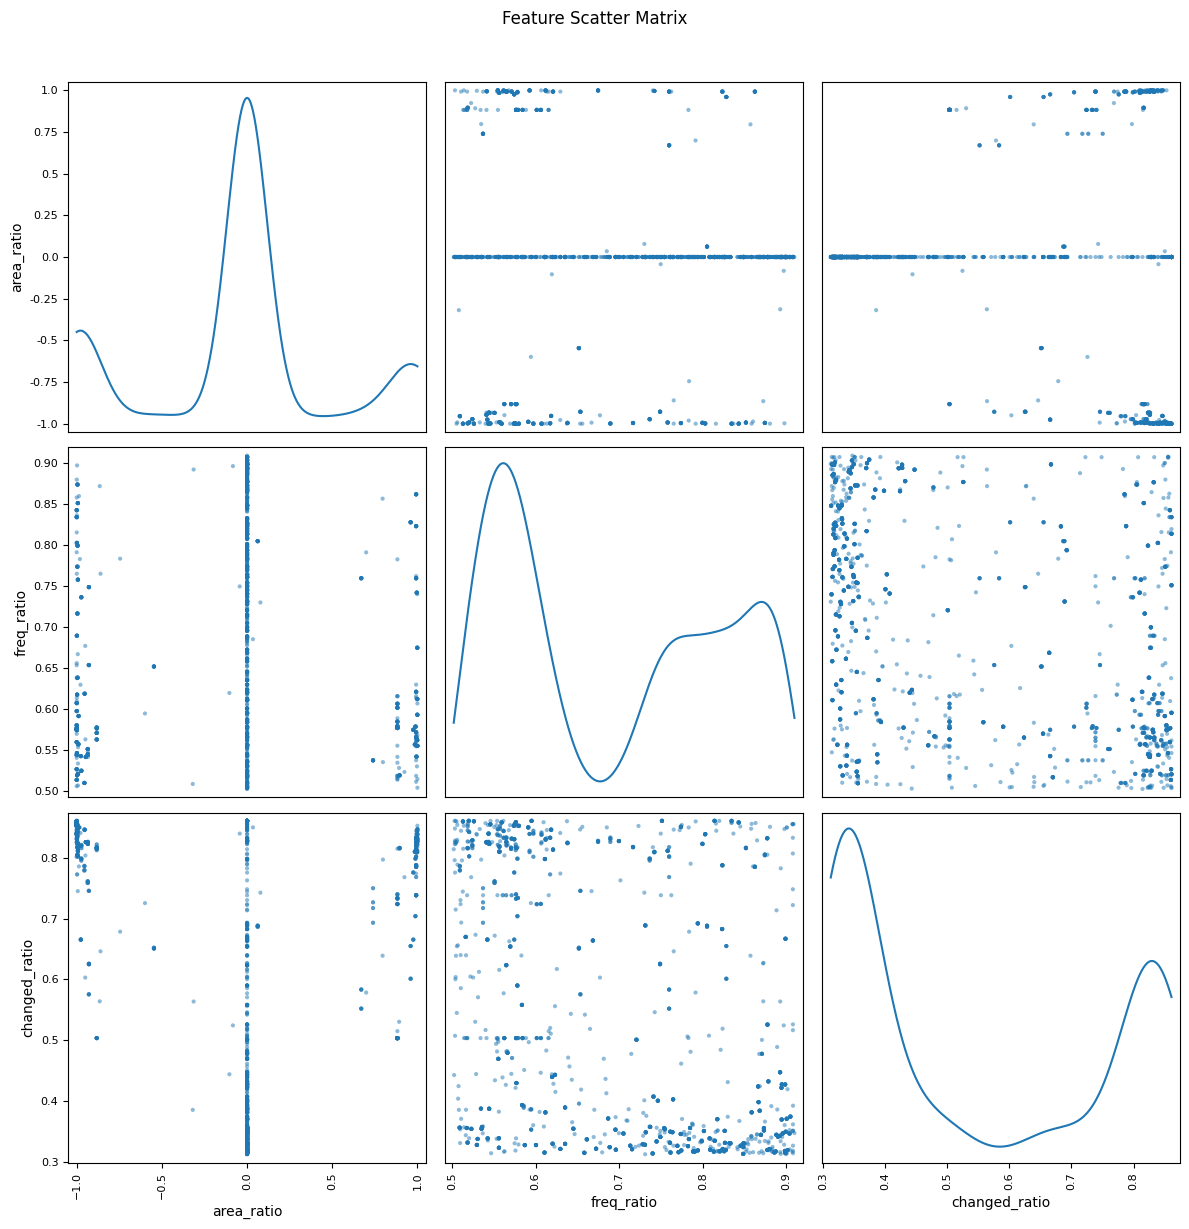

In [9]:
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

# df_clusters: 기존 DataFrame
df = df_clusters

# representative 피처 리스트
features = [col for col in df.columns if col.endswith('_representative')]

# 산점도 매트릭스 생성
sm = scatter_matrix(
    df[features],
    figsize=(12, 12),
    diagonal='kde',
    alpha=0.5
)

# 축 레이블에서 '_representative' 제거
for ax in sm.ravel():
    # X축 레이블 교체
    xlabel = ax.get_xlabel()
    if xlabel.endswith('_representative'):
        ax.set_xlabel(xlabel.replace('_representative', ''), fontsize=10)
    # Y축 레이블 교체
    ylabel = ax.get_ylabel()
    if ylabel.endswith('_representative'):
        ax.set_ylabel(ylabel.replace('_representative', ''), fontsize=10)

plt.suptitle('Feature Scatter Matrix', y=1.02)
plt.tight_layout()
plt.show()

/home/student/.conda/envs/project/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/home/student/.conda/envs/project/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/home/student/.conda/envs/project/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)


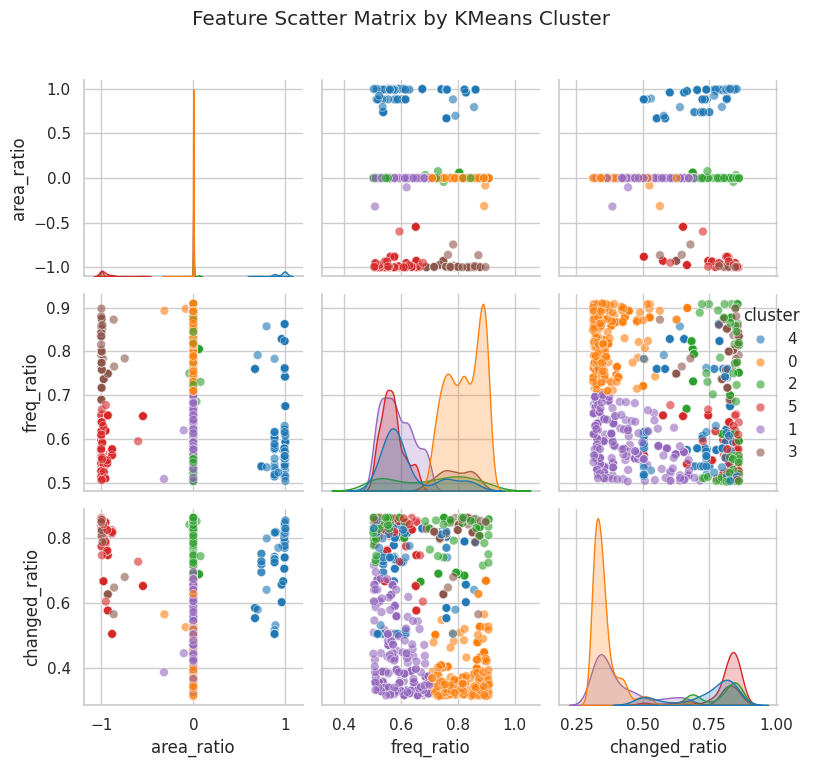

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df_clusters: index가 task 이름, 'cluster' 컬럼 포함
df = df_clusters.copy()

# representative 피처 리스트
features = [col for col in df.columns if col.endswith('_representative')]

# plot 전용 DataFrame 준비
df_plot = df[features].rename(columns=lambda s: s.replace('_representative', ''))
df_plot['cluster'] = df['cluster'].astype(str)  # hue로 사용하기 위해 문자열로 변환

# seaborn pairplot으로 scatter matrix + hue
sns.set(style='whitegrid', palette='tab10')
pp = sns.pairplot(
    df_plot,
    vars=df_plot.columns[:-1],    # 피처들
    hue='cluster',                # 클러스터 라벨
    diag_kind='kde',
    plot_kws={'alpha':0.6, 's':40},  # 점 투명도, 크기
    diag_kws={'shade':True}
)

pp.fig.suptitle('Feature Scatter Matrix by KMeans Cluster', y=1.02)
plt.tight_layout()
plt.show()


In [11]:

import plotly.express as px

# df_plot에 'cluster' 컬럼이 str 형태로 있다고 가정
fig = px.scatter_3d(
    df_plot,
    x=features[0].replace('_representative',''),
    y=features[1].replace('_representative',''),
    z=features[2].replace('_representative',''),
    color='cluster',
    opacity=0.7,
    size_max=6,
    title='Interactive 3D Scatter by KMeans Cluster'
)
fig.update_layout(scene=dict(
    xaxis_title=features[0].replace('_representative',''),
    yaxis_title=features[1].replace('_representative',''),
    zaxis_title=features[2].replace('_representative',''),
))
fig.show()


In [12]:
task_list_1_by_label =[[] for _ in range(n_cluster)]
for task in task_list_1:
    task_list_1_by_label[task.label].append(task)
for i in range(n_cluster):
    print(f"cluster {i} : {len(task_list_1_by_label[i])} tasks")
print("===================================")
task_list_2_by_label =[[] for _ in range(n_cluster)]
for task in task_list_2:
    task_list_2_by_label[task.label].append(task)
for i in range(n_cluster):
    print(f"cluster {i} : {len(task_list_2_by_label[i])} tasks")
print("=============total===============")
for i in range(n_cluster):
    print(f"cluster {i} : {len(task_list_1_by_label[i]) + len(task_list_2_by_label[i])} tasks")


cluster 0 : 657 tasks
cluster 1 : 349 tasks
cluster 2 : 105 tasks
cluster 3 : 100 tasks
cluster 4 : 227 tasks
cluster 5 : 276 tasks
cluster 0 : 110 tasks
cluster 1 : 81 tasks
cluster 2 : 55 tasks
cluster 3 : 8 tasks
cluster 4 : 33 tasks
cluster 5 : 8 tasks
=============total===============
cluster 0 : 767 tasks
cluster 1 : 430 tasks
cluster 2 : 160 tasks
cluster 3 : 108 tasks
cluster 4 : 260 tasks
cluster 5 : 284 tasks


In [24]:
target_task_1 = [101, 85, 85, 87, 67, 175]
target_task_2 = [87, 46, 35, 8, 16, 8]
print(sum(target_task_1))
print(sum(target_task_2))
# target 개수에 맞게, 랜덤하게 taask_list_1 및 task_list_2에서 task를 선택
task_list_1_selected = []
task_list_2_selected = []
for i in range(n_cluster):
    task_list_1_selected += random.sample(task_list_1_by_label[i], target_task_1[i])
    task_list_2_selected += random.sample(task_list_2_by_label[i], target_task_2[i])



600
200


In [25]:
# task_list_1의 class 분포가 의도한 것과 같은지 확인
task_list_1_selected_by_label = [[] for _ in range(n_cluster)]
for task in task_list_1_selected:
    task_list_1_selected_by_label[task.label].append(task)
for i in range(n_cluster):
    print(f"cluster {i} : {len(task_list_1_selected_by_label[i])} tasks")
print("===================================")
# task_list_2의 class 분포가 의도한 것과 같은지 확인
task_list_2_selected_by_label = [[] for _ in range(n_cluster)]
for task in task_list_2_selected:
    task_list_2_selected_by_label[task.label].append(task)
for i in range(n_cluster):
    print(f"cluster {i} : {len(task_list_2_selected_by_label[i])} tasks")
print("===================================")

cluster 0 : 101 tasks
cluster 1 : 85 tasks
cluster 2 : 85 tasks
cluster 3 : 87 tasks
cluster 4 : 67 tasks
cluster 5 : 175 tasks
cluster 0 : 87 tasks
cluster 1 : 46 tasks
cluster 2 : 35 tasks
cluster 3 : 8 tasks
cluster 4 : 16 tasks
cluster 5 : 8 tasks


In [29]:
task_list_final = task_list_1_selected + task_list_2_selected
class_counts = [0] * n_cluster
for task in task_list_final:
    label,_ = task.classify_task('artifacts/cluster_model_fixed')
    class_counts[label] += 1
print(class_counts)

[188, 131, 120, 95, 83, 183]


In [30]:
DATASET_DIR_LIST = ["/home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset","/home/student/subin_workspace/2025DL-team-project/workspace/dataset_generated"]

dataset_final_dir = "/home/student/subin_workspace/2025DL-team-project/workspace/dataset_final"
# dataset_dir_list의 json 중 task_list_final에 포함된 task의 json 파일만 모아서 dataset_final_dir에 복사해 저장
import os
import shutil
if not os.path.exists(dataset_final_dir):
    os.makedirs(dataset_final_dir)
for task in task_list_final:    
    task_name = task.name+ ".json"
    for dataset_dir in DATASET_DIR_LIST:
        json_file_path = os.path.join(dataset_dir, task_name)
        if os.path.exists(json_file_path):
            shutil.copy(json_file_path, dataset_final_dir)
            print(f"Copied {task_name} to {dataset_final_dir}")
            break
    else:
        print(f"{task_name} not found in any dataset directory")

Copied /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/ecdecbb3_tp2.json to /home/student/subin_workspace/2025DL-team-project/workspace/dataset_final
Copied /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/f25ffba3_tp2.json to /home/student/subin_workspace/2025DL-team-project/workspace/dataset_final
Copied /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/3906de3d.json to /home/student/subin_workspace/2025DL-team-project/workspace/dataset_final
Copied /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/0a938d79.json to /home/student/subin_workspace/2025DL-team-project/workspace/dataset_final
Copied /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/d89b689b_tp1.json to /home/student/subin_workspace/2025DL-team-project/workspace/dataset_final
Copied /home/student/subin_workspace/2025DL-team-project/workspace/augmented_dataset/1bfc4729_rt3.json to /h